In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import linregress

In [4]:
import pandas as pd

# Load cleaned datasets
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

print("NAV Shape:", nav.shape)
print("Performance Shape:", performance.shape)

display(nav.head())
display(performance.head())

NAV Shape: (46000, 3)
Performance Shape: (40, 20)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False


In [5]:
print("NAV Columns")
print(nav.columns.tolist())

print("\nPerformance Columns")
print(performance.columns.tolist())

NAV Columns
['amfi_code', 'date', 'nav']

Performance Columns
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'anomaly']


In [6]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

display(nav.head())

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
# Daily Return = (Today's NAV / Yesterday's NAV) - 1
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

display(nav.head(10))

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
# Summary statistics
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


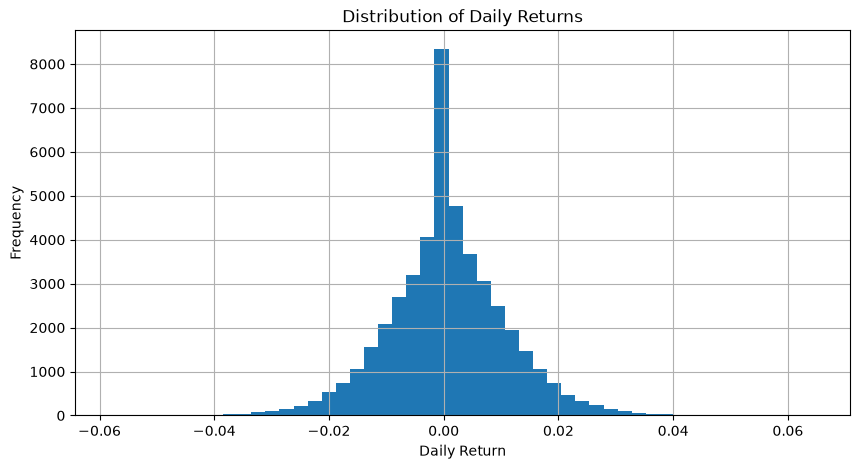

In [9]:
plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [10]:
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [11]:
# Latest date in dataset
latest_date = nav["date"].max()
print("Latest Date:", latest_date)

Latest Date: 2026-05-29 00:00:00


In [12]:
def calculate_cagr(start_nav, end_nav, years):
    if start_nav <= 0 or end_nav <= 0:
        return np.nan
    return (end_nav / start_nav) ** (1 / years) - 1

In [13]:
from pandas import DateOffset

# Dates for CAGR calculation
one_year_date = latest_date - DateOffset(years=1)
three_year_date = latest_date - DateOffset(years=3)
five_year_date = latest_date - DateOffset(years=5)

cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    latest_nav = group.iloc[-1]["nav"]

    # 1 Year
    one_data = group[group["date"] >= one_year_date]
    cagr_1 = np.nan
    if len(one_data) > 1:
        start_nav = one_data.iloc[0]["nav"]
        cagr_1 = calculate_cagr(start_nav, latest_nav, 1)

    # 3 Year
    three_data = group[group["date"] >= three_year_date]
    cagr_3 = np.nan
    if len(three_data) > 1:
        start_nav = three_data.iloc[0]["nav"]
        cagr_3 = calculate_cagr(start_nav, latest_nav, 3)

    # 5 Year
    five_data = group[group["date"] >= five_year_date]
    cagr_5 = np.nan
    if len(five_data) > 1:
        start_nav = five_data.iloc[0]["nav"]
        cagr_5 = calculate_cagr(start_nav, latest_nav, 5)

    cagr_results.append({
        "amfi_code": amfi_code,
        "CAGR_1Y": cagr_1,
        "CAGR_3Y": cagr_3,
        "CAGR_5Y": cagr_5
    })

cagr_df = pd.DataFrame(cagr_results)

display(cagr_df.head())

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [14]:
cagr_df = cagr_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

display(cagr_df.head())

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth


In [15]:
cagr_df.to_csv("../data/processed/cagr_comparison.csv", index=False)

print("CAGR comparison table saved successfully!")

CAGR comparison table saved successfully!


In [16]:
# Risk-free rate (6.5%)
rf = 0.065

In [17]:
sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        annual_return = returns.mean() * 252
        annual_volatility = returns.std() * np.sqrt(252)

        sharpe = (annual_return - rf) / annual_volatility

    else:
        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

display(sharpe_df.head())

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [18]:
sharpe_df = sharpe_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

display(sharpe_df.head())

,amfi_code,Sharpe_Ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [19]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["Rank"] = sharpe_df.index + 1

display(sharpe_df.head(10))

,amfi_code,Sharpe_Ratio,scheme_name,Rank
0,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1
1,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,2
2,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3
3,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
4,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5
5,149323,1.132122,DSP Midcap Fund - Regular - Growth,6
6,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
7,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,8
8,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9
9,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10


In [20]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio saved successfully!")

Sharpe Ratio saved successfully!


In [21]:
sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        annual_return = returns.mean() * 252

        # Downside returns only
        downside_returns = returns[returns < 0]

        if len(downside_returns) > 1:

            downside_std = downside_returns.std() * np.sqrt(252)

            sortino = (annual_return - rf) / downside_std

        else:
            sortino = np.nan

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

display(sortino_df.head())

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [22]:
sortino_df = sortino_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

display(sortino_df.head())

,amfi_code,Sortino_Ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [23]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["Rank"] = sortino_df.index + 1

display(sortino_df.head(10))

,amfi_code,Sortino_Ratio,scheme_name,Rank
0,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,1
1,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,2
2,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,3
3,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,4
4,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,5
5,149323,1.875101,DSP Midcap Fund - Regular - Growth,6
6,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,7
7,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8
8,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,9
9,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,10


In [24]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


In [25]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.shape)
display(benchmark.head())

(8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [26]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [27]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

display(benchmark.head())

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [28]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

display(nifty100.head())

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [29]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

display(nifty100.head())

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [30]:
merged = nav.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

display(merged.head())

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [31]:
from scipy.stats import linregress

alpha_beta = []

for amfi_code, group in merged.groupby("amfi_code"):

    data = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(data) > 30:

        slope, intercept, r, p, stderr = linregress(
            data["benchmark_return"],
            data["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": amfi_code,
            "Alpha": intercept * 252,
            "Beta": slope
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

display(alpha_beta_df.head())

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [32]:
alpha_beta_df = alpha_beta_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

display(alpha_beta_df.head())

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [33]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha & Beta saved successfully!")

Alpha & Beta saved successfully!


In [34]:
drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1

    # Maximum Drawdown
    max_dd = group["drawdown"].min()

    # Date of maximum drawdown
    max_dd_date = group.loc[group["drawdown"].idxmin(), "date"]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "Maximum_Drawdown": max_dd,
        "Worst_Drawdown_Date": max_dd_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

display(drawdown_df.head())

,amfi_code,Maximum_Drawdown,Worst_Drawdown_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [35]:
drawdown_df = drawdown_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

display(drawdown_df.head())

,amfi_code,Maximum_Drawdown,Worst_Drawdown_Date,scheme_name
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [36]:
drawdown_df = drawdown_df.sort_values(
    "Maximum_Drawdown"
)

display(drawdown_df.head(10))

,amfi_code,Maximum_Drawdown,Worst_Drawdown_Date,scheme_name
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth


In [37]:
drawdown_df.to_csv(
    "../data/processed/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown saved successfully!")

Maximum Drawdown saved successfully!


In [38]:
scorecard = performance[
    ["amfi_code", "scheme_name", "return_3yr_pct", "expense_ratio_pct"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code",
    how="left"
)

display(scorecard.head())

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287


In [39]:
# Higher is better
scorecard["Return_Rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)
scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

# Lower expense ratio is better
scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

# Smaller drawdown (less negative) is better
scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

display(scorecard.head())

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124,26.0,4.0,10.0,30.5,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035,34.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742,2.0,32.0,36.0,5.5,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,9.0,5.0


In [40]:
scorecard["Score"] = (
    (41 - scorecard["Return_Rank"]) * 0.30 +
    (41 - scorecard["Sharpe_Rank"]) * 0.25 +
    (41 - scorecard["Alpha_Rank"]) * 0.20 +
    (41 - scorecard["Expense_Rank"]) * 0.15 +
    (41 - scorecard["Drawdown_Rank"]) * 0.10
)

# Convert to 0–100 scale
scorecard["Fund_Score"] = (
    scorecard["Score"] / scorecard["Score"].max()
) * 100

display(scorecard.head())

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Score,Fund_Score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124,26.0,4.0,10.0,30.5,17.0,23.925,74.765625
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035,34.0,12.0,15.0,4.0,11.0,23.100,72.187500
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,30.250,94.531250
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742,2.0,32.0,36.0,5.5,40.0,20.375,63.671875
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287,38.0,37.0,34.0,9.0,5.0,11.700,36.562500


In [41]:
scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

scorecard["Overall_Rank"] = scorecard.index + 1

display(scorecard.head(10))

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Score,Fund_Score,Overall_Rank
0,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,32.000,100.000000,1
1,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,31.600,98.750000,2
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,30.500,95.312500,3
3,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,30.250,94.531250,4
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,30.000,93.750000,5
5,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,26.5,37.0,27.875,87.109375,6
6,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,38.0,22.0,27.300,85.312500,7
7,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,12.0,12.0,26.900,84.062500,8
8,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,17.0,28.0,26.600,83.125000,9
9,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,36.5,21.0,24.975,78.046875,10


In [42]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


In [43]:
top5 = scorecard.head(5)["amfi_code"].tolist()

print(top5)

[120505, 120843, 100033, 119598, 148567]


In [44]:
top5_nav = nav[nav["amfi_code"].isin(top5)].copy()

top5_nav = top5_nav.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

display(top5_nav.head())

,amfi_code,date,nav,daily_return,scheme_name
0,100033,2022-01-03,107.3758,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,100033,2022-01-04,105.9447,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,100033,2022-01-05,105.4800,-0.004386,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,100033,2022-01-06,104.9350,-0.005167,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,100033,2022-01-07,104.3318,-0.005748,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [45]:
start_date = latest_date - pd.DateOffset(years=3)

top5_nav = top5_nav[top5_nav["date"] >= start_date]

nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty50 = nifty50[nifty50["date"] >= start_date]
nifty100 = nifty100[nifty100["date"] >= start_date]

In [46]:
top5_nav["Normalized"] = top5_nav.groupby("amfi_code")["nav"].transform(
    lambda x: x / x.iloc[0] * 100
)

nifty50["Normalized"] = (
    nifty50["close_value"] / nifty50["close_value"].iloc[0]
) * 100

nifty100["Normalized"] = (
    nifty100["close_value"] / nifty100["close_value"].iloc[0]
) * 100

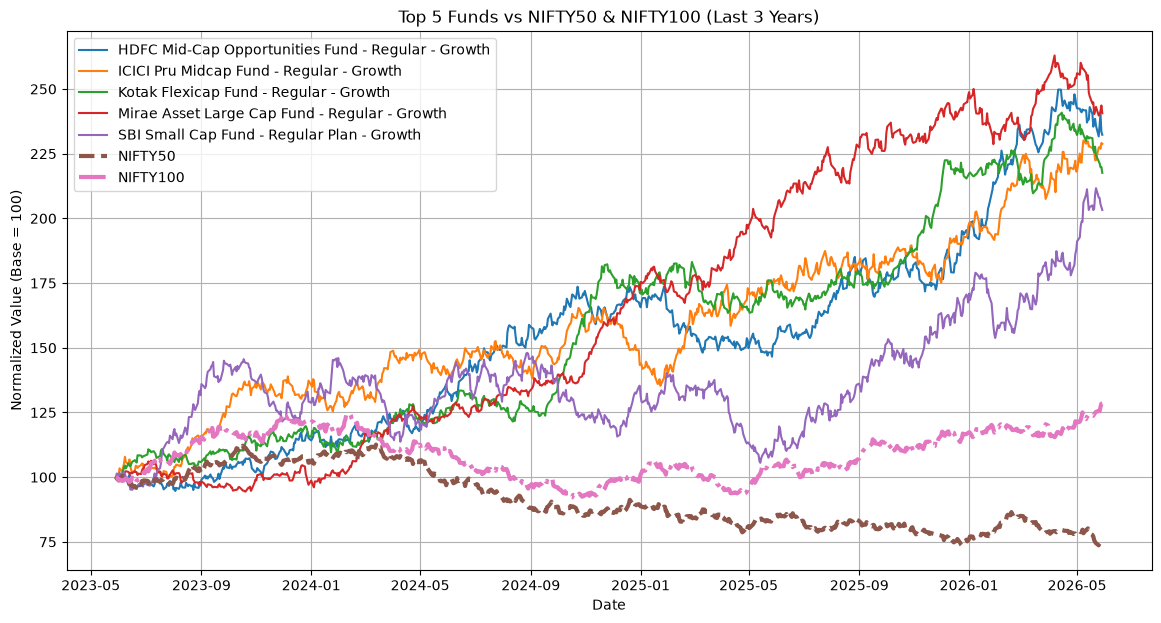

In [47]:
plt.figure(figsize=(14,7))

# Top 5 Funds
for name, group in top5_nav.groupby("scheme_name"):
    plt.plot(group["date"], group["Normalized"], label=name)

# Benchmarks
plt.plot(
    nifty50["date"],
    nifty50["Normalized"],
    linewidth=3,
    linestyle="--",
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["Normalized"],
    linewidth=3,
    linestyle="-.",
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig("../charts/benchmark_comparison.png", dpi=300)

plt.show()

In [48]:
tracking_error = []

for amfi_code, group in merged.groupby("amfi_code"):

    diff = group["daily_return"] - group["benchmark_return"]

    te = diff.std() * np.sqrt(252)

    tracking_error.append({
        "amfi_code": amfi_code,
        "Tracking_Error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df = tracking_error_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

display(tracking_error_df.head())

,amfi_code,Tracking_Error,scheme_name
0,100016,0.199284,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.134535,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.192706,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.292117,ABSL Small Cap Fund - Regular - Growth


In [49]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully!")

Tracking Error saved successfully!
